# OM4 simulation with ANN

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


In [2]:
exp_dic = {}

exp_dic['no_param'] = {'path':'/scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/', 'cu':0, 'cb':0}
exp_dic['uann'] = {'path':'/scratch/pp2681/mom6/OM4_SIS2/ANN-greenline/output/', 'cu':1, 'cb':0}
exp_dic['bann_1'] = {'path':'/scratch/db194/OM4/test_ANN_20Dec_torch_5yr/output/', 'cu':0, 'cb':1}
exp_dic['bann_1p75'] = {'path':'/scratch/db194/OM4/test_ANN_20Dec_torch_5yr_ANN_1p75/output/', 'cu':0, 'cb':1.75}
exp_dic['bann_2p5'] = {'path':'/scratch/db194/OM4/test_ANN_20Dec_torch_5yr_ANN_2p5/output/', 'cu':0, 'cb':2.5}
exp_dic['bann_5p0'] = {'path':'/scratch/db194/OM4/test_ANN_20Dec_torch_5yr_ANN_5p0/output/', 'cu':0, 'cb':5.0}
exp_dic['meke_gm_0.2'] = {'path':'/scratch/db194/OM4/OM4_MEKE_GM/output/', 'cu':0, 'cb':-0.2}
exp_dic['meke_gm_0.4'] = {'path':'/scratch/db194/OM4/OM4_MEKE_GM_2/output/', 'cu':0, 'cb':-0.4}
exp_dic['meke_gm_0.8'] = {'path':'/scratch/db194/OM4/OM4_MEKE_GM_4/output/', 'cu':0, 'cb':-0.8}
exp_dic['bann_c1_uann_c1'] = {'path':'/home/db194/scratch_db194/OM4/test_bANN_20Dec_C1_uANN_C1/output/', 'cu':1, 'cb':1}
exp_dic['bann_c1p75_uann_c1'] = {'path':'/home/db194/scratch_db194/OM4/test_bANN_20Dec_C1p75_uANN_C1/output/', 'cu':1, 'cb':1.75}
exp_dic['bann_c1p75_uann_c1p75'] = {'path':'/home/db194/scratch_db194/OM4/test_bANN_20Dec_C1p75_uANN_C1p75/output/', 'cu':1.75, 'cb':1.75}


In [3]:
for key in exp_dic.keys():
    print(f'Loading dataset for experiment: {key}')
    exp_dic[key]['os'] = xr.open_dataset(exp_dic[key]['path'] + 'ocean.stats.nc', decode_times=False)

Loading dataset for experiment: no_param
Loading dataset for experiment: uann
Loading dataset for experiment: bann_1
Loading dataset for experiment: bann_1p75
Loading dataset for experiment: bann_2p5
Loading dataset for experiment: bann_5p0
Loading dataset for experiment: meke_gm_0.2
Loading dataset for experiment: meke_gm_0.4
Loading dataset for experiment: meke_gm_0.8
Loading dataset for experiment: bann_c1_uann_c1
Loading dataset for experiment: bann_c1p75_uann_c1
Loading dataset for experiment: bann_c1p75_uann_c1p75


## Bulk Statistics 

In [4]:
jump = exp_dic['no_param']['os'].APE.sum('Interface').isel(Time=10) - exp_dic['bann_5p0']['os'].APE.sum('Interface').isel(Time=10)

In [5]:
exp_dic['no_param']['os']

<xarray.Dataset> Size: 19MB
Dimensions:        (Time: 7305, Interface: 76, Layer: 75)
Coordinates:
  * Time           (Time) float64 58kB 7.212e+05 7.212e+05 ... 7.231e+05
  * Interface      (Interface) float64 608B 0.0 2.0 4.0 ... 3.722e+03 6.5e+03
  * Layer          (Layer) float64 600B 1.0 3.0 5.0 ... 3.591e+03 5.111e+03
Data variables: (12/18)
    Ntrunc         (Time) float64 58kB ...
    En             (Time) float64 58kB ...
    APE            (Time, Interface) float64 4MB 7.075e+17 2.384e+15 ... 0.0
    KE             (Time, Layer) float64 4MB ...
    H0             (Time, Interface) float64 4MB ...
    Mass_lay       (Time, Layer) float64 4MB ...
    ...             ...
    Salt_chg       (Time) float64 58kB ...
    Salt_anom      (Time) float64 58kB ...
    Heat           (Time) float64 58kB ...
    Heat_chg       (Time) float64 58kB ...
    Heat_anom      (Time) float64 58kB ...
    age            (Time) float64 58kB ...
Attributes:
    filename:  ./ocean.stats.nc

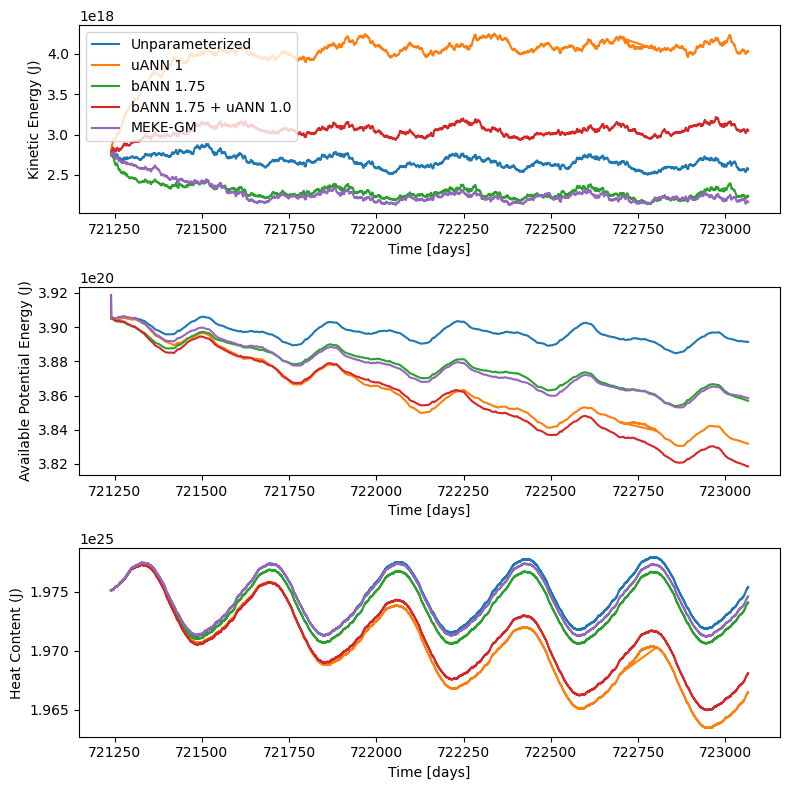

In [13]:
plt.figure(figsize=(8,8))

keys_to_plot = ['no_param', 'uann', 'bann_1p75', 'bann_c1p75_uann_c1', 'meke_gm_0.2']
labels = ['Unparameterized', 'uANN 1', 'bANN 1.75', 'bANN 1.75 + uANN 1.0', 'MEKE-GM']

plt.subplot(3,1,1)
for key in keys_to_plot:
    label_str = labels[keys_to_plot.index(key)]
    #if key == 'meke_gm':
    #    label_str='MEKE'
    exp_dic[key]['os'].KE.sum('Layer').plot(label=label_str)
    #exp_dic[key]['os'].Heat.plot(label=label_str)
plt.ylabel('Kinetic Energy (J)')

plt.legend()


plt.subplot(3,1,2)
for key in keys_to_plot:
    if key == 'no_param' or key == 'uann':
        (exp_dic[key]['os'].APE.sum('Interface') - jump.values).plot(label=f"cu={exp_dic[key]['cu']}, cb={exp_dic[key]['cb']}")
    else:
        exp_dic[key]['os'].APE.sum('Interface').plot(label=f"cu={exp_dic[key]['cu']}, cb={exp_dic[key]['cb']}")

plt.ylabel('Available Potential Energy (J)')

plt.subplot(3,1,3)
for key in keys_to_plot:
    exp_dic[key]['os'].Heat.plot(label=label_str)

plt.ylabel('Heat Content (J)')


plt.tight_layout()

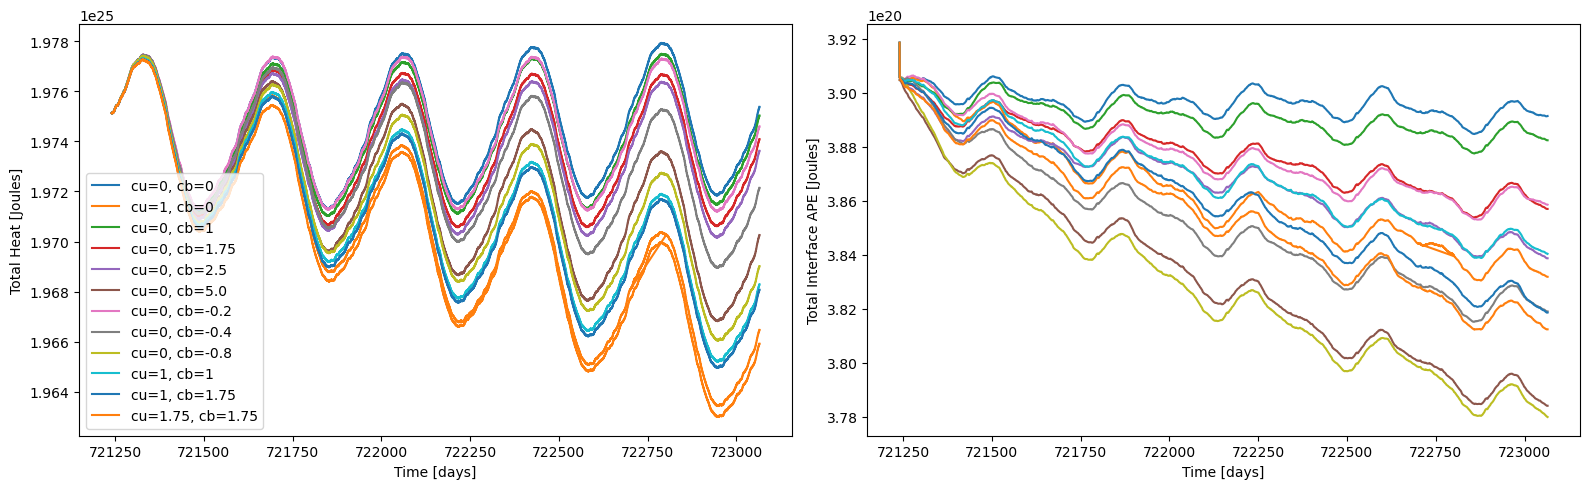

In [12]:
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
for key in exp_dic.keys():
    label_str = f"cu={exp_dic[key]['cu']}, cb={exp_dic[key]['cb']}"
    if key == 'meke_gm':
        label_str='MEKE'
    #exp_dic[key]['os'].KE.sum('Layer').plot(label=label_str)
    exp_dic[key]['os'].Heat.plot(label=label_str)


plt.legend()


plt.subplot(1,2,2)
for key in exp_dic.keys():
    if key == 'no_param' or key == 'uann':
        (exp_dic[key]['os'].APE.sum('Interface') - jump.values).plot(label=f"cu={exp_dic[key]['cu']}, cb={exp_dic[key]['cb']}")
    else:
        exp_dic[key]['os'].APE.sum('Interface').plot(label=f"cu={exp_dic[key]['cu']}, cb={exp_dic[key]['cb']}")


plt.tight_layout()

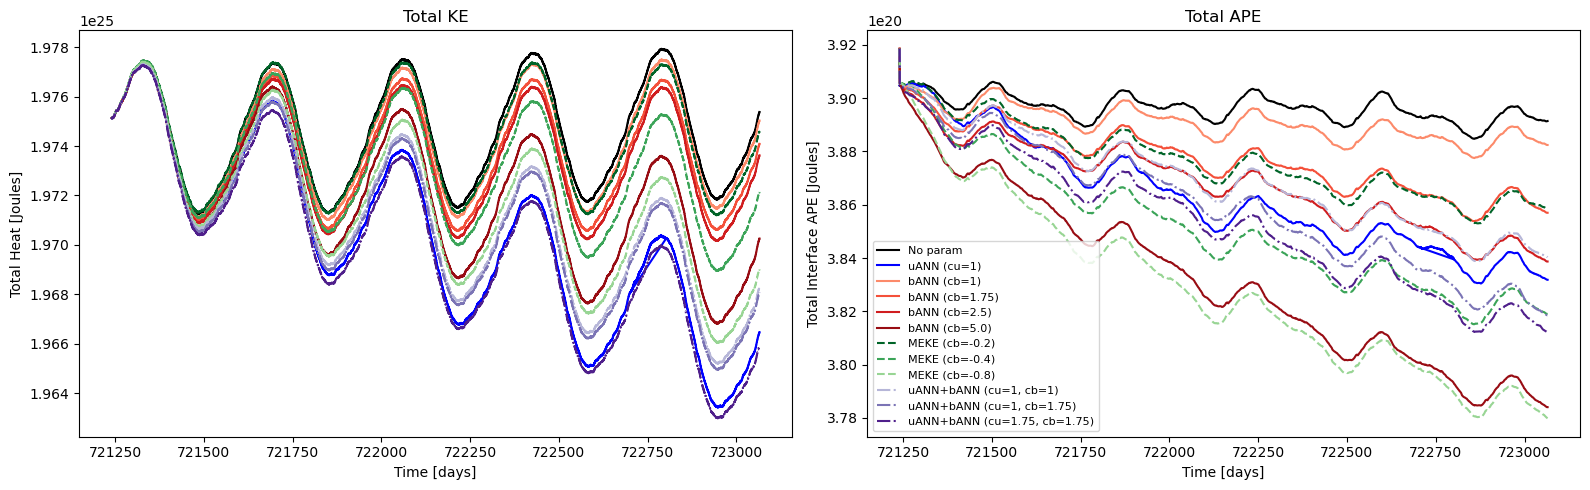

In [14]:
import matplotlib.cm as cm

def get_exp_style(key, exp, exp_dic):
    """Return linestyle, color, and label based on experiment type."""
    cu, cb = exp['cu'], exp['cb']
    
    if cu == 0 and cb == 0:  # No parameterization
        return '-', 'black', 'No param'
    
    elif cu > 0 and cb == 0:  # Momentum ANN only
        return '-', 'blue', f'uANN (cu={cu})'
    
    elif cu == 0 and cb < 0:  # MEKE-GM
        meke_exps = {k: v for k, v in exp_dic.items() if v['cu'] == 0 and v['cb'] < 0}
        meke_cbs = sorted([v['cb'] for v in meke_exps.values()])
        idx = meke_cbs.index(cb)
        colors = cm.Greens(np.linspace(0.4, 0.9, len(meke_cbs)))
        return '--', colors[idx], f'MEKE (cb={cb})'
    
    elif cu == 0 and cb > 0:  # Buoyancy ANN only
        bann_exps = {k: v for k, v in exp_dic.items() if v['cu'] == 0 and v['cb'] > 0}
        bann_cbs = sorted([v['cb'] for v in bann_exps.values()])
        idx = bann_cbs.index(cb)
        colors = cm.Reds(np.linspace(0.4, 0.9, len(bann_cbs)))
        return '-', colors[idx], f'bANN (cb={cb})'
    
    elif cu > 0 and cb > 0:  # Combined
        combined_exps = {k: v for k, v in exp_dic.items() if v['cu'] > 0 and v['cb'] > 0}
        combined_keys = sorted(combined_exps.keys())
        idx = combined_keys.index(key)
        colors = cm.Purples(np.linspace(0.4, 0.9, len(combined_keys)))
        return '-.', colors[idx], f'uANN+bANN (cu={cu}, cb={cb})'
    
    else:
        return ':', 'gray', f'cu={cu}, cb={cb}'

plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
for key in exp_dic.keys():
    ls, color, label = get_exp_style(key, exp_dic[key], exp_dic)
    #exp_dic[key]['os'].KE.sum('Layer').plot(label=label, color=color, linestyle=ls)
    exp_dic[key]['os'].Heat.plot(label=label, color=color, linestyle=ls)
#plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.title('Total KE')

plt.subplot(1,2,2)
for key in exp_dic.keys():
    ls, color, label = get_exp_style(key, exp_dic[key], exp_dic)
    if key == 'no_param' or key == 'uann':
        (exp_dic[key]['os'].APE.sum('Interface') - jump.values).plot(label=label, color=color, linestyle=ls)
    else:
        exp_dic[key]['os'].APE.sum('Interface').plot(label=label, color=color, linestyle=ls)
plt.legend( loc='lower left', fontsize=8)
#plt.legend(bbox_to_anchor=(1.02, 1), loc='upper right', fontsize=8)
plt.title('Total APE')

plt.tight_layout()

In [7]:
for key in exp_dic.keys():
    exp_dic[key]['delta_APE'] = exp_dic[key]['os'].APE.sum('Interface').isel(Time=-1) - ( exp_dic['no_param']['os'].APE.sum('Interface') -jump.values).isel(Time=-1)
    if key == 'no_param' or key == 'uann':
        exp_dic[key]['delta_APE'] = exp_dic[key]['os'].APE.sum('Interface').isel(Time=-1) - (exp_dic['no_param']['os'].APE.sum('Interface') ).isel(Time=-1)
    
    exp_dic[key]['delta_KE'] = exp_dic[key]['os'].KE.sum('Layer').isel(Time=slice(-3000,None)).mean('Time') - exp_dic['no_param']['os'].KE.sum('Layer').isel(Time=slice(-3000,None)).mean('Time')

/ext3/miniforge3/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


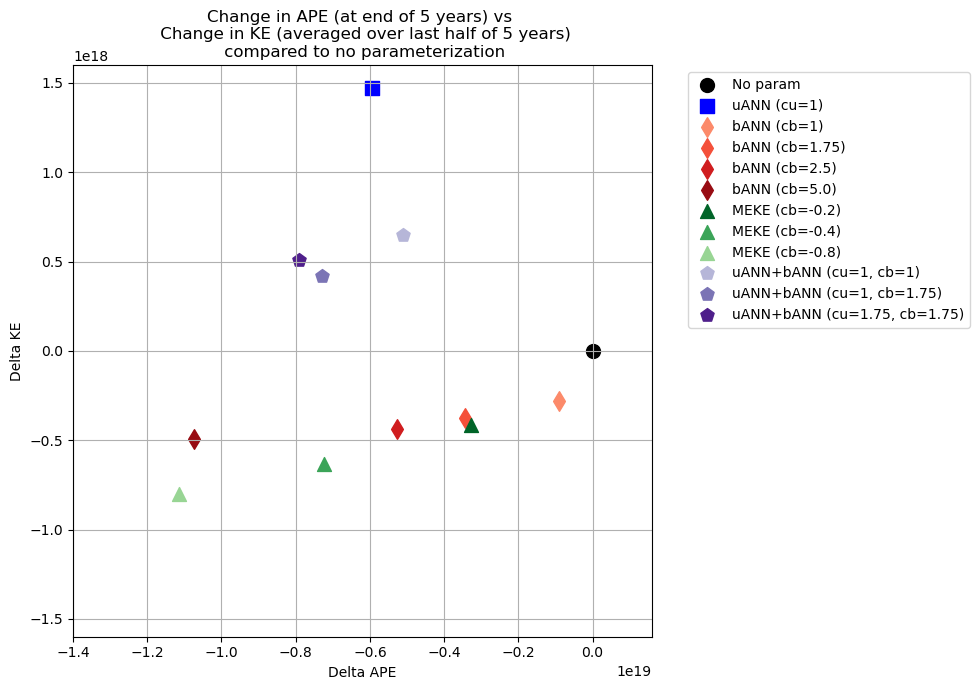

In [8]:
# Define experiment categories and their markers/colors
# Define colormaps for each category
import matplotlib.cm as cm

def get_exp_style(key, exp, exp_dic):
    """Return marker, color, and label based on experiment type."""
    cu, cb = exp['cu'], exp['cb']
    
    if cu == 0 and cb == 0:  # No parameterization
        return 'o', 'black', 'No param'
    
    elif cu > 0 and cb == 0:  # Momentum ANN only
        return 's', 'blue', f'uANN (cu={cu})'
    
    elif cu == 0 and cb < 0:  # MEKE-GM
        # Get all MEKE experiments and assign colors from green colormap
        meke_exps = {k: v for k, v in exp_dic.items() if v['cu'] == 0 and v['cb'] < 0}
        meke_cbs = sorted([v['cb'] for v in meke_exps.values()])
        idx = meke_cbs.index(cb)
        colors = cm.Greens(np.linspace(0.4, 0.9, len(meke_cbs)))
        return '^', colors[idx], f'MEKE (cb={cb})'
    
    elif cu == 0 and cb > 0:  # Buoyancy ANN only
        # Get all bANN-only experiments and assign colors from red colormap
        bann_exps = {k: v for k, v in exp_dic.items() if v['cu'] == 0 and v['cb'] > 0}
        bann_cbs = sorted([v['cb'] for v in bann_exps.values()])
        idx = bann_cbs.index(cb)
        colors = cm.Reds(np.linspace(0.4, 0.9, len(bann_cbs)))
        return 'd', colors[idx], f'bANN (cb={cb})'
    
    elif cu > 0 and cb > 0:  # Combined
        # Get all combined experiments and assign colors from purple colormap
        combined_exps = {k: v for k, v in exp_dic.items() if v['cu'] > 0 and v['cb'] > 0}
        combined_keys = sorted(combined_exps.keys())
        idx = combined_keys.index(key)
        colors = cm.Purples(np.linspace(0.4, 0.9, len(combined_keys)))
        return 'p', colors[idx], f'uANN+bANN (cu={cu}, cb={cb})'
    
    else:
        return 'x', 'gray', f'cu={cu}, cb={cb}'

# Plotting with different markers
plt.figure(figsize=(10, 7))

for key in exp_dic.keys():
    marker, color, label = get_exp_style(key, exp_dic[key], exp_dic)
    plt.scatter(exp_dic[key]['delta_APE'], exp_dic[key]['delta_KE'], 
                marker=marker, color=color, s=100, label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim([-1.6e18, 1.6e18])
plt.xlim([-1.4e19, 1.6e18])
plt.grid(True)
plt.xlabel('Delta APE')
plt.ylabel('Delta KE')
plt.title('Change in APE (at end of 5 years) vs \n Change in KE (averaged over last half of 5 years)\n compared to no parameterization')
plt.tight_layout()

In [9]:
import re
from pathlib import Path

def get_runtime(exp_path):
    """Extract first runtime value from latest slurm*.out file (one level up from output/)."""
    exp_folder = Path(exp_path).parent
    
    # Find all slurm files and sort by number to get latest
    slurm_files = list(exp_folder.glob("slurm*.out"))
    if not slurm_files:
        return None
    
    # Extract numbers from filenames and sort descending
    def get_slurm_number(f):
        match = re.search(r'slurm-(\d+)\.out', f.name)
        return int(match.group(1)) if match else 0
    
    latest_slurm = max(slurm_files, key=get_slurm_number)
    
    try:
        for line in latest_slurm.read_text(errors="ignore").splitlines():
            if line.startswith("Total runtime"):
                values = re.findall(r'\d+(?:\.\d+)?', line)
                if values:
                    return float(values[0])
    except Exception:
        pass
    return None

# Extract runtimes for all experiments
runtimes = {}
for key in exp_dic.keys():
    exp_path = exp_dic[key]['path']
    runtime = get_runtime(exp_path)
    runtimes[key] = runtime
    if runtime:
        print(f"{key}: {runtime:.1f} s ({runtime/3600:.2f} hrs)")
    else:
        print(f"{key}: not found")

no_param: 25107.0 s (6.97 hrs)
uann: 32261.1 s (8.96 hrs)
bann_1: 103550.4 s (28.76 hrs)
bann_1p75: 107638.5 s (29.90 hrs)
bann_2p5: 129382.0 s (35.94 hrs)
bann_5p0: 105174.2 s (29.22 hrs)
meke_gm_0.2: 133510.5 s (37.09 hrs)
meke_gm_0.4: 115453.0 s (32.07 hrs)
meke_gm_0.8: 114717.3 s (31.87 hrs)
bann_c1_uann_c1: 156539.4 s (43.48 hrs)
bann_c1p75_uann_c1: 118504.3 s (32.92 hrs)
bann_c1p75_uann_c1p75: 120181.3 s (33.38 hrs)


### Delta KE vs Delta APE plots 

## Simulated fields

In [21]:
ds_daily_1 = xr.open_mfdataset(path + '19770101.ocean_daily_*.nc')


In [25]:
ds_monthly_1 = xr.open_mfdataset(path + '19770101.ocean_month_*.nc')


In [22]:
ds_daily_2 = xr.open_mfdataset(path2 + '19770101.ocean_daily_*.nc')


In [26]:
ds_monthly_2 = xr.open_mfdataset(path2 + '19770101.ocean_month_*.nc')

In [27]:
ds_noparam_month = xr.open_mfdataset(path_no_param + '19770101.ocean_month_*.nc')

In [22]:
def load_monthly_files(path, drop_last=1, pattern_month='*ocean_month_[0-9]*.nc',
                       pattern_month_z='*ocean_month_z_[0-9]*.nc', open_kwargs=None):
    """
    Collect, optionally drop last N monthly files, open them, and report.
    Parameters
    ----------
    path : str
        Directory containing MOM6 output.
    drop_last : int
        Number of files to drop from the tail of each list.
    pattern_month : str
        Glob pattern (joined to path) for 2D monthly files.
    pattern_month_z : str
        Glob pattern (joined to path) for z-level monthly files.
    open_kwargs : dict or None
        Extra kwargs passed to xr.open_dataset (e.g. {'decode_times': False}).
    Returns
    -------
    month_files : list[str]
    month_z_files : list[str]
    ds_months : list[xr.Dataset]
    dsz_months : list[xr.Dataset]
    """
    if open_kwargs is None:
        open_kwargs = {}
    month_files = sorted(glob.glob(path + pattern_month))
    month_z_files = sorted(glob.glob(path + pattern_month_z))

    if drop_last > 0:
        month_files = month_files[:-drop_last] if len(month_files) > drop_last else []
        month_z_files = month_z_files[:-drop_last] if len(month_z_files) > drop_last else []

    print(f"Found {len(month_files)} ocean_month files (after dropping {drop_last}):")
    for f in month_files:
        print(f"  {f}")
    print(f"\nFound {len(month_z_files)} ocean_month_z files (after dropping {drop_last}):")
    for f in month_z_files:
        print(f"  {f}")

    ds_months = [xr.open_dataset(f, **open_kwargs) for f in month_files]
    dsz_months = [xr.open_dataset(f, **open_kwargs) for f in month_z_files]

    print(f"\nLoaded {len(ds_months)} ocean_month datasets")
    print(f"Loaded {len(dsz_months)} ocean_month_z datasets")
    return month_files, month_z_files, ds_months, dsz_months



In [21]:
# Example (replicates previous behavior dropping 1):
month_files, month_z_files, ds_months, dsz_months = load_monthly_files(path, drop_last=1)

Found 4 ocean_month files (after dropping 1):
  /home/db194/scratch_db194/OM4/test_ANN_20Nov/19770101.ocean_month_00721255.nc
  /home/db194/scratch_db194/OM4/test_ANN_20Nov/19770101.ocean_month_00721620.nc
  /home/db194/scratch_db194/OM4/test_ANN_20Nov/19770101.ocean_month_00721985.nc
  /home/db194/scratch_db194/OM4/test_ANN_20Nov/19770101.ocean_month_00722350.nc

Found 4 ocean_month_z files (after dropping 1):
  /home/db194/scratch_db194/OM4/test_ANN_20Nov/19770101.ocean_month_z_00721255.nc
  /home/db194/scratch_db194/OM4/test_ANN_20Nov/19770101.ocean_month_z_00721620.nc
  /home/db194/scratch_db194/OM4/test_ANN_20Nov/19770101.ocean_month_z_00721985.nc
  /home/db194/scratch_db194/OM4/test_ANN_20Nov/19770101.ocean_month_z_00722350.nc

Loaded 4 ocean_month datasets
Loaded 4 ocean_month_z datasets


In [23]:
_, _, ds_months_noparam, dsz_months_noparam = load_monthly_files(path_no_param, drop_last=1)

Found 4 ocean_month files (after dropping 1):
  /scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/19770101.ocean_month_00721255.nc
  /scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/19780101.ocean_month_00721620.nc
  /scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/19790101.ocean_month_00721985.nc
  /scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/19800101.ocean_month_00722350.nc

Found 4 ocean_month_z files (after dropping 1):
  /scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/19770101.ocean_month_z_00721255.nc
  /scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/19780101.ocean_month_z_00721620.nc
  /scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/19790101.ocean_month_z_00721985.nc
  /scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/19800101.ocean_month_z_00722350.nc

Loaded 4 ocean_month datasets
Loaded 4 ocean_month_z datasets


In [24]:
ds_grid = xr.open_dataset(path + 'ocean_geometry.nc').rename({'lonh': 'xh', 'lath': 'yh', 'lonq': 'xq', 'latq': 'yq'})
ds_grid

<xarray.Dataset> Size: 236MB
Dimensions:  (yh: 1080, xh: 1440, yq: 1080, xq: 1440)
Coordinates:
  * yh       (yh) float64 9kB -80.39 -80.31 -80.23 -80.15 ... 89.73 89.84 89.95
  * xh       (xh) float64 12kB -299.7 -299.5 -299.2 -299.0 ... 59.53 59.78 60.03
  * yq       (yq) float64 9kB -80.35 -80.27 -80.19 -80.11 ... 89.78 89.89 90.0
  * xq       (xq) float64 12kB -299.6 -299.3 -299.1 -298.9 ... 59.66 59.91 60.16
Data variables: (12/19)
    geolatb  (yq, xq) float64 12MB ...
    geolonb  (yq, xq) float64 12MB ...
    geolat   (yh, xh) float64 12MB ...
    geolon   (yh, xh) float64 12MB ...
    D        (yh, xh) float64 12MB ...
    f        (yq, xq) float64 12MB ...
    ...       ...
    dyBu     (yq, xq) float64 12MB ...
    Ah       (yh, xh) float64 12MB ...
    Aq       (yq, xq) float64 12MB ...
    dxCvo    (yq, xh) float64 12MB ...
    dyCuo    (yh, xq) float64 12MB ...
    wet      (yh, xh) float64 12MB ...
Attributes:
    filename:  ./ocean_geometry.nc

In [29]:
ds_monthly_1

<xarray.Dataset> Size: 159GB
Dimensions:         (time: 60, z_l: 35, yh: 1080, xh: 1440, xq: 1440, yq: 1080,
                     z_i: 36, nv: 2)
Coordinates:
  * xh              (xh) float64 12kB -299.7 -299.5 -299.2 ... 59.53 59.78 60.03
  * yh              (yh) float64 9kB -80.39 -80.31 -80.23 ... 89.73 89.84 89.95
  * z_l             (z_l) float64 280B 2.5 10.0 20.0 ... 5.5e+03 6e+03 6.5e+03
  * z_i             (z_i) float64 288B 0.0 5.0 15.0 ... 6.25e+03 6.75e+03
  * time            (time) object 480B 1977-01-16 12:00:00 ... 1981-12-16 12:...
  * nv              (nv) float64 16B 1.0 2.0
  * xq              (xq) float64 12kB -299.6 -299.3 -299.1 ... 59.66 59.91 60.16
  * yq              (yq) float64 9kB -80.35 -80.27 -80.19 ... 89.78 89.89 90.0
Data variables: (12/17)
    so              (time, z_l, yh, xh) float32 13GB dask.array<chunksize=(12, 35, 1080, 1440), meta=np.ndarray>
    uo              (time, z_l, yh, xq) float32 13GB dask.array<chunksize=(12, 35, 1080, 1440), meta=np.ndarray>
    vo              (time, z_l, yq, xh) float32 13GB dask.array<chunksize=(12, 35, 1080, 1440), meta=np.ndarray>
    thetao          (time, z_l, yh, xh) float32 13GB dask.array<chunksize=(12, 35, 1080, 1440), meta=np.ndarray>
    vmo             (time, z_l, yq, xh) float32 13GB dask.array<chunksize=(12, 35, 1080, 1440), meta=np.ndarray>
    umo             (time, z_l, yh, xq) float32 13GB dask.array<chunksize=(12, 35, 1080, 1440), meta=np.ndarray>
    ...              ...
    vhGM            (time, z_l, yq, xh) float32 13GB dask.array<chunksize=(12, 35, 1080, 1440), meta=np.ndarray>
    average_T1      (time) datetime64[ns] 480B dask.array<chunksize=(12,), meta=np.ndarray>
    average_T2      (time) datetime64[ns] 480B dask.array<chunksize=(12,), meta=np.ndarray>
    average_DT      (time) timedelta64[ns] 480B dask.array<chunksize=(12,), meta=np.ndarray>
    time_bnds       (time, nv) timedelta64[ns] 960B dask.array<chunksize=(12, 2), meta=np.ndarray>
    MLD_003         (time, yh, xh) float32 373MB dask.array<chunksize=(12, 1080, 1440), meta=np.ndarray>
Attributes:
    filename:   19770101.ocean_month_z_00721255.nc
    title:      OM4_SIS2_cgrid_025
    grid_type:  regular
    grid_tile:  N/A

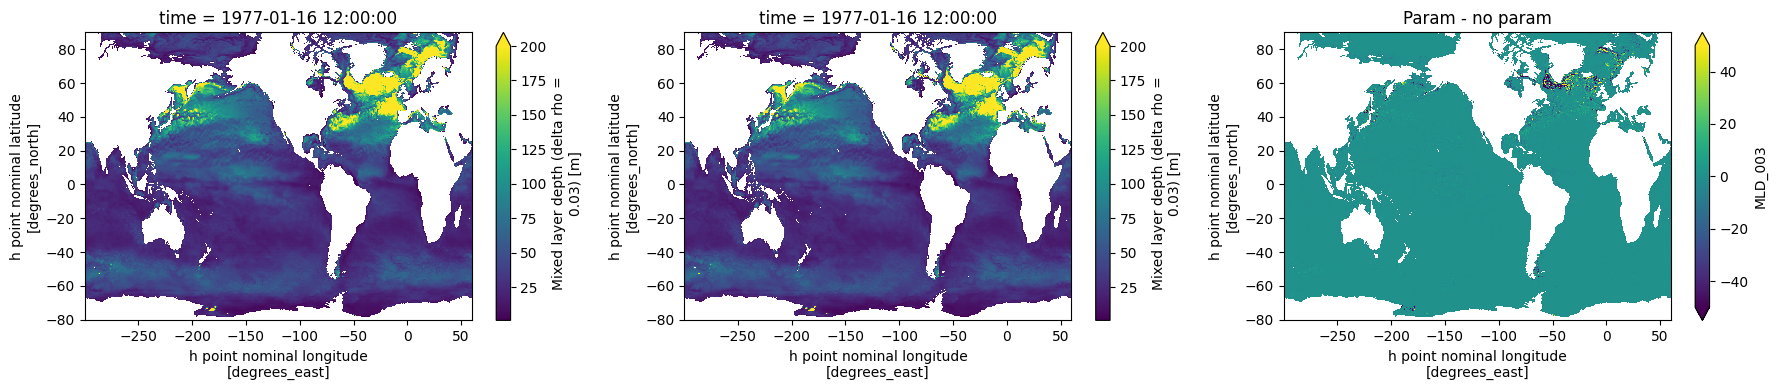

In [30]:
plt.figure(figsize=(18,4))
time_id = 0

plt.subplot(1,3,1)
ds_monthly_1.MLD_003.isel(time=time_id).plot(vmax=200)

plt.subplot(1,3,2)
ds_noparam_month.MLD_003.isel(time=time_id).plot(vmax=200)

plt.subplot(1,3,3)
(ds_monthly_1.MLD_003.isel(time=time_id) - ds_noparam_month.MLD_003.isel(time=time_id)).plot(vmax=50, vmin=-50)
plt.title('Param - no param')

plt.tight_layout()

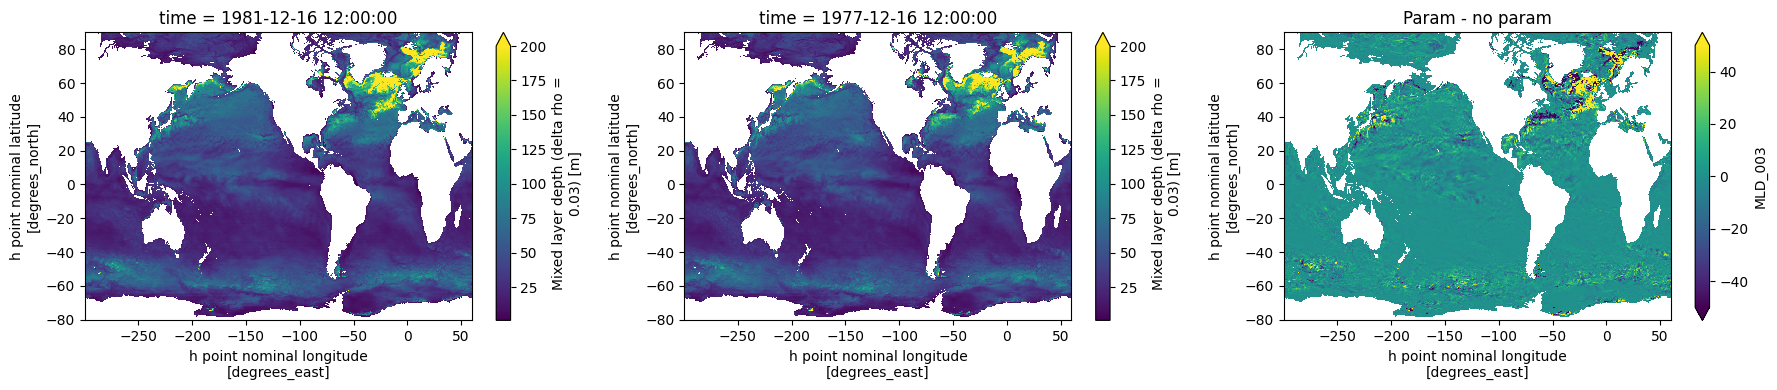

In [31]:
plt.figure(figsize=(18,4))
time_id = -1

plt.subplot(1,3,1)
ds_monthly_1.MLD_003.isel(time=time_id).plot(vmax=200)

plt.subplot(1,3,2)
ds_noparam_month.MLD_003.isel(time=time_id).plot(vmax=200)

plt.subplot(1,3,3)
(ds_monthly_1.MLD_003.isel(time=time_id) - ds_noparam_month.MLD_003.isel(time=time_id)).plot(vmax=50, vmin=-50)
plt.title('Param - no param')

plt.tight_layout()

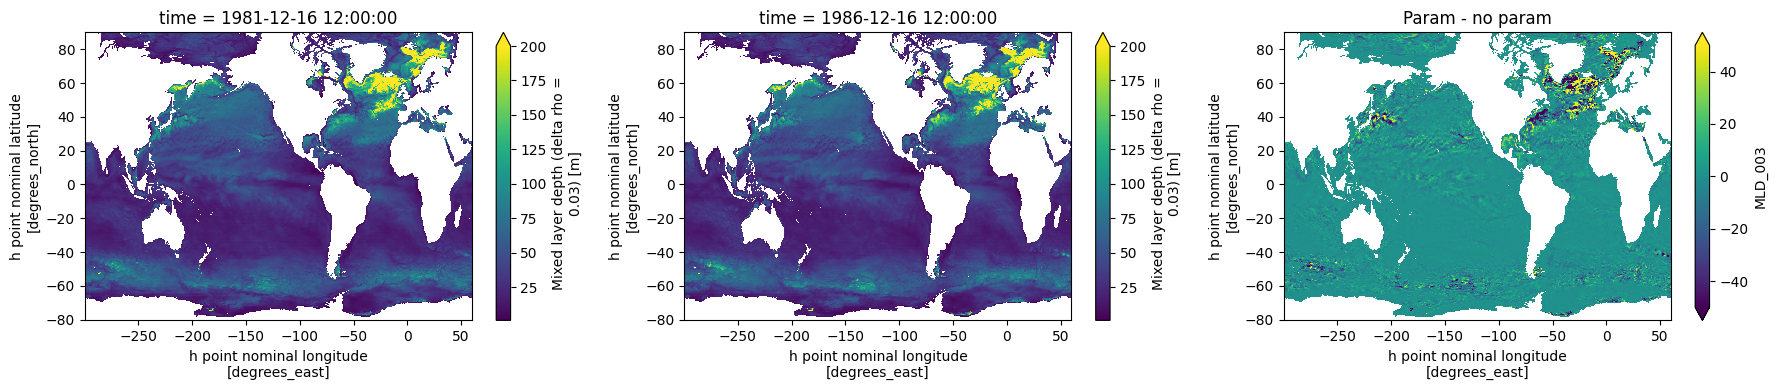

In [32]:
plt.figure(figsize=(18,4))
time_id = -1

plt.subplot(1,3,1)
ds_monthly_1.MLD_003.isel(time=time_id).plot(vmax=200)

plt.subplot(1,3,2)
ds_monthly_2.MLD_003.isel(time=time_id).plot(vmax=200)

plt.subplot(1,3,3)
(ds_monthly_1.MLD_003.isel(time=time_id) - ds_monthly_2.MLD_003.isel(time=time_id)).plot(vmax=50, vmin=-50)
plt.title('Param - no param')

plt.tight_layout()

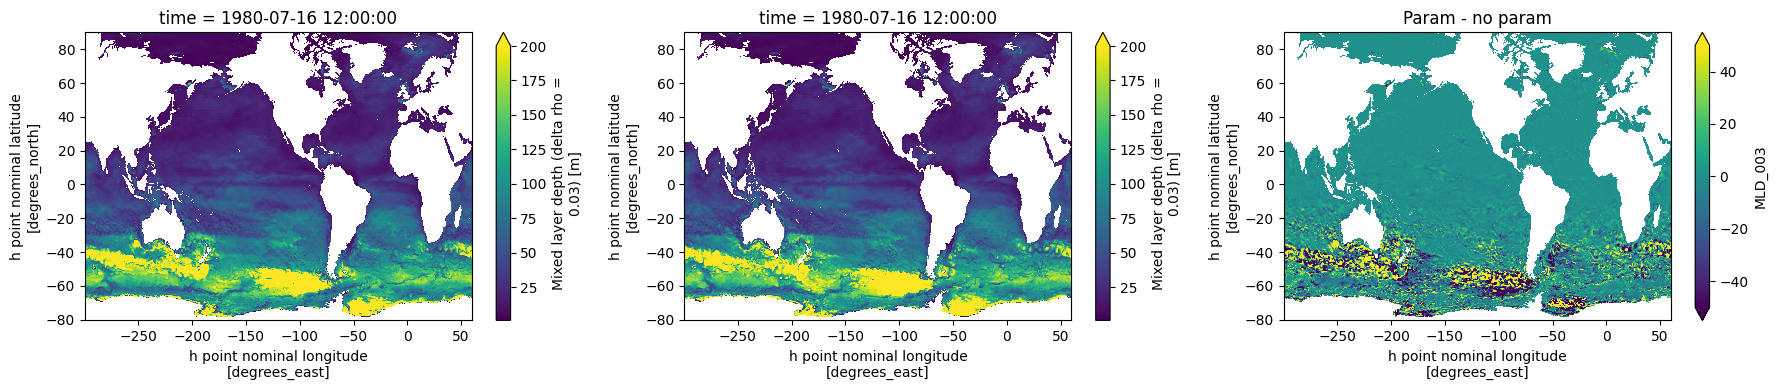

In [27]:
plt.figure(figsize=(18,4))

plt.subplot(1,3,1)
ds_months[-1].MLD_003.isel(time=6).plot(vmax=200)

plt.subplot(1,3,2)
ds_months_noparam[-1].MLD_003.isel(time=6).plot(vmax=200)

plt.subplot(1,3,3)
(ds_months[-1].MLD_003.isel(time=6) - ds_months_noparam[-1].MLD_003.isel(time=6)).plot(vmax=50, vmin=-50)
plt.title('Param - no param')

plt.tight_layout()

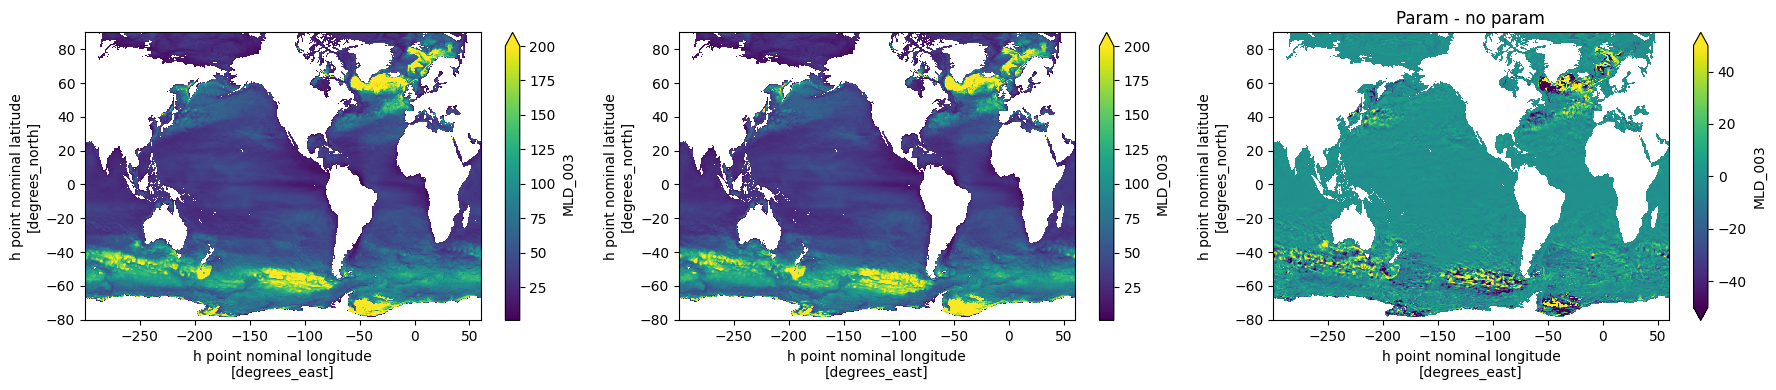

In [28]:
plt.figure(figsize=(18,4))

plt.subplot(1,3,1)
ds_months[-1].MLD_003.mean('time').plot(vmax=200)

plt.subplot(1,3,2)
ds_months_noparam[-1].MLD_003.mean('time').plot(vmax=200)

plt.subplot(1,3,3)
(ds_months[-1].MLD_003.mean('time') - ds_months_noparam[-1].MLD_003.mean('time')).plot(vmax=50, vmin=-50)
plt.title('Param - no param')

plt.tight_layout()

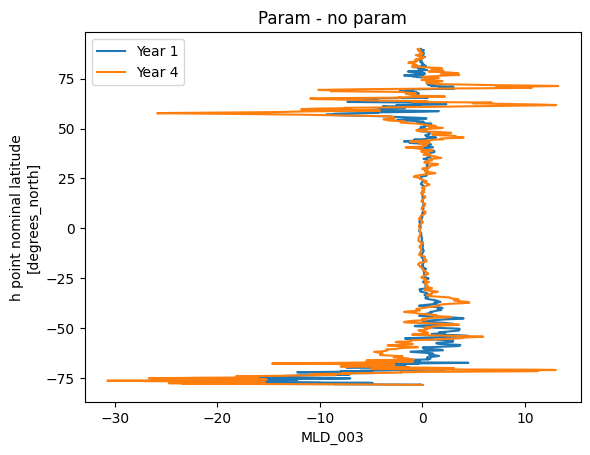

In [33]:
(ds_months[0].MLD_003.mean('time') - ds_months_noparam[0].MLD_003.mean('time')).mean('xh').plot(label='Year 1', y ='yh')
(ds_months[-1].MLD_003.mean('time') - ds_months_noparam[-1].MLD_003.mean('time')).mean('xh').plot(label='Year 4', y ='yh')
plt.title('Param - no param')
plt.legend()

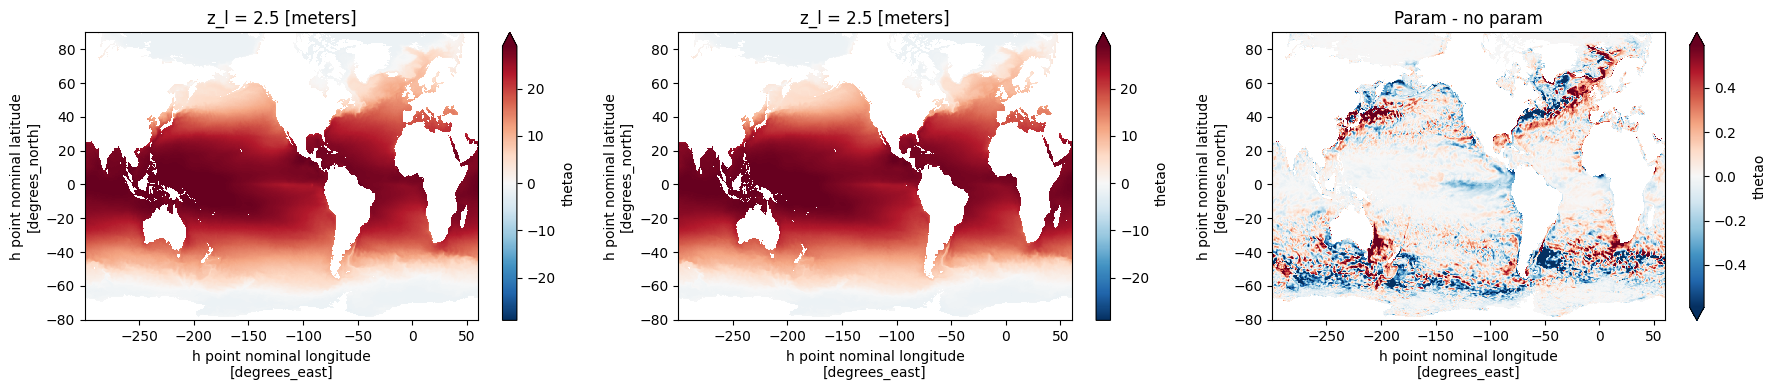

In [43]:
plt.figure(figsize=(18,4))

plt.subplot(1,3,1)
dsz_months[-1].thetao.isel(z_l=0).mean('time').plot(robust=True)

plt.subplot(1,3,2)
dsz_months_noparam[-1].thetao.isel(z_l=0).mean('time').plot(robust=True)

plt.subplot(1,3,3)
(dsz_months[-1].thetao.isel(z_l=0).mean('time') - dsz_months_noparam[-1].thetao.isel(z_l=0).mean('time')).plot(robust=True)
plt.title('Param - no param')

plt.tight_layout()

In [45]:
np.linspace(-2.25,2.25,10)

array([-2.25, -1.75, -1.25, -0.75, -0.25,  0.25,  0.75,  1.25,  1.75,
        2.25])

Text(0.5, 1.0, 'Param - no param')

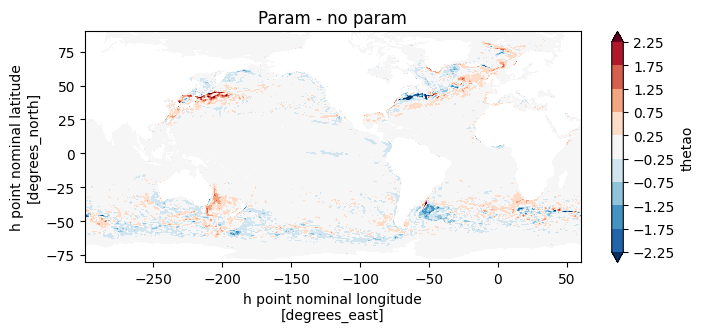

In [ ]:
plt.figure(figsize  =(8,3))
(dsz_months_1[-1].thetao.isel(z_l=0).mean('time') - dsz_months_noparam[-1].thetao.isel(z_l=0).mean('time')).plot(levels=np.linspace(-2.25,2.25,10))
plt.title('Param - no param')

Text(0.5, 1.0, 'Param - no param')

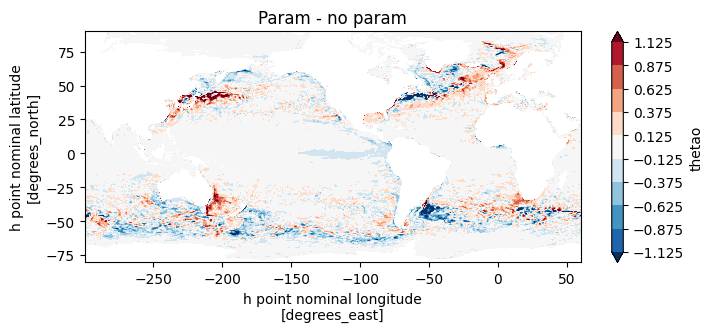

In [47]:
plt.figure(figsize  =(8,3))
(dsz_months[-1].thetao.isel(z_l=0).mean('time') - dsz_months_noparam[-1].thetao.isel(z_l=0).mean('time')).plot(levels=np.linspace(-2.25/2,2.25/2,10))
plt.title('Param - no param')

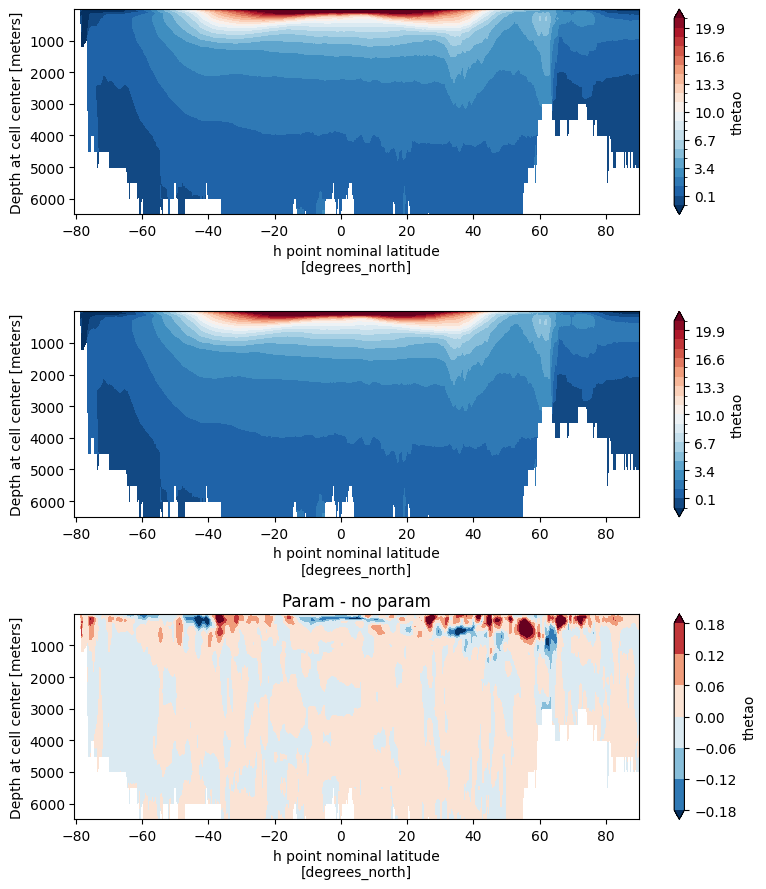

In [42]:
plt.figure(figsize=(8,9))

plt.subplot(3,1,1)
dsz_months[-1].thetao.mean(['time','xh']).plot.contourf(vmin=-1, vmax=21, levels=21, cmap='RdBu_r')
plt.gca().invert_yaxis()

plt.subplot(3,1,2)
dsz_months_noparam[-1].thetao.mean(['time','xh']).plot.contourf(vmin=-1, vmax=21, levels=21, cmap='RdBu_r')
plt.gca().invert_yaxis()

plt.subplot(3,1,3)
(dsz_months[-1].thetao.mean(['time','xh']) - dsz_months_noparam[-1].thetao.mean(['time','xh'])).plot.contourf(robust=True)
plt.gca().invert_yaxis()
plt.title('Param - no param')

plt.tight_layout()

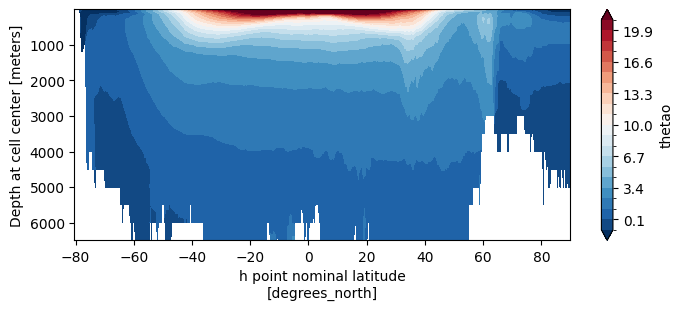

In [40]:
plt.figure(figsize=(8,3))

dsz_months_noparam[-1].thetao.mean(['time','xh']).plot.contourf(vmin=-1, vmax=21, levels=21, cmap='RdBu_r')
plt.gca().invert_yaxis()

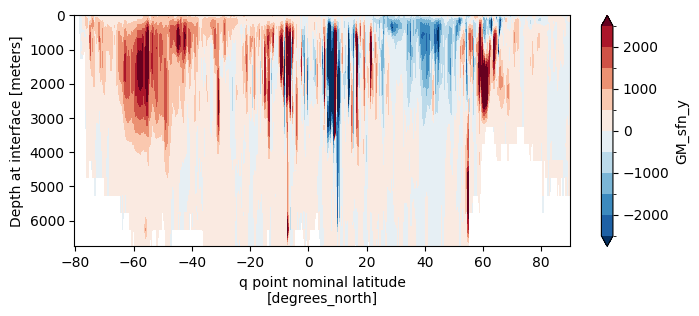

In [18]:
plt.figure(figsize=(8,3))

dsz_months[-1].GM_sfn_y.mean(['time','xh']).plot.contourf(vmin=-2500, levels=11)
plt.gca().invert_yaxis()

In [ ]:
plt.figure(figsize=(8,3))

dsz_months[-1].GM_sfn_y.mean(['time','xh']).plot.contourf(vmin=-2500, levels=11)
plt.gca().invert_yaxis()

In [13]:
#def add_ups(ds):

ups_y = dsz_month_1.GM_sfn_unlim_y/ds_grid.dyCv

In [14]:
from xgcm import Grid

In [15]:
grid = Grid(dsz_month_1, coords={'X': {'center': 'xh', 'right': 'xq'},
                            'Y': {'center': 'yh', 'right': 'yq'},
                            'Z': {'center': 'z_l', 'outer': 'z_i'} }, periodic=['X'])

In [16]:
vstar = grid.diff(ups_y, 'Z', boundary='extend') / grid.diff(dsz_month_1.z_i, 'Z', boundary='extend')

/ext3/miniconda3/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


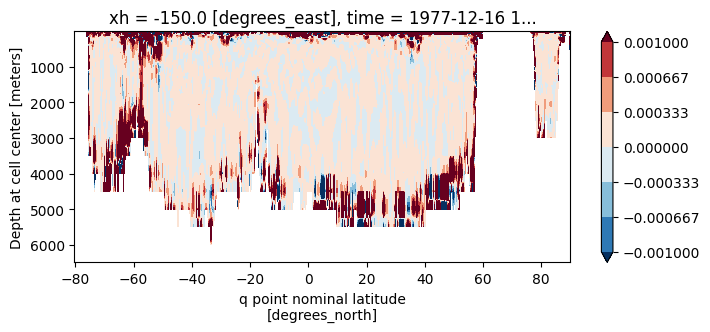

In [19]:
plt.figure(figsize=(8,3))

vstar.isel(time=-1).sel(xh=-150, method='nearest').plot.contourf(vmin=-1e-3)
plt.gca().invert_yaxis()

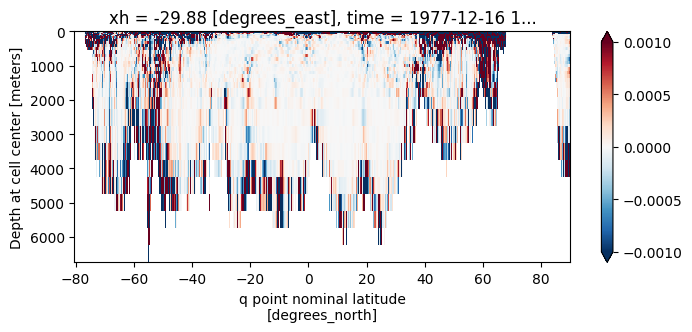

In [21]:
plt.figure(figsize=(8,3))

vstar.isel(time=-1).sel(xh=-30, method='nearest').plot(vmin=-1e-3)
plt.gca().invert_yaxis()

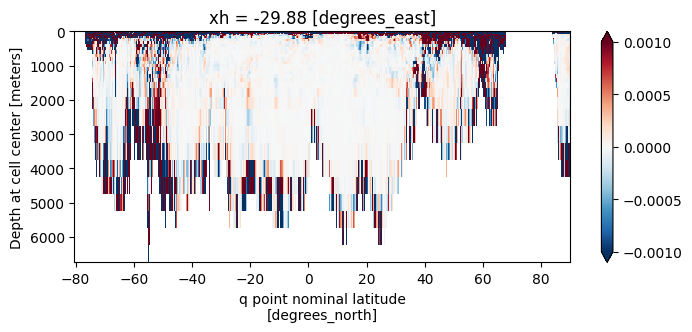

In [22]:
plt.figure(figsize=(8,3))

vstar.mean('time').sel(xh=-30, method='nearest').plot(vmin=-1e-3)
plt.gca().invert_yaxis()

In [ ]:
plt.figure(figsize=(8,3))

vstar.mean('time').sel(xh=-30, method='nearest').plot(vmin=-1e-3)
plt.gca().invert_yaxis()

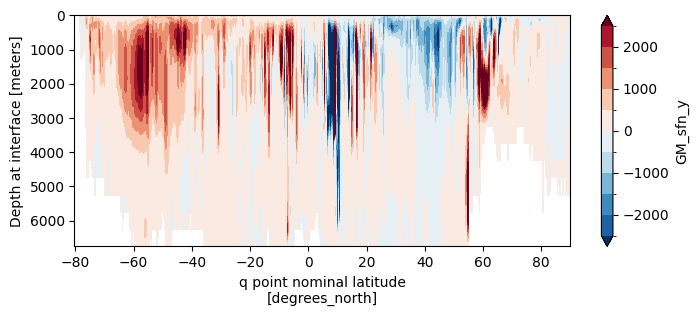

In [27]:
plt.figure(figsize=(8,3))

dsz_month_2.GM_sfn_y.mean(['time','xh']).plot.contourf(vmin=-2500, levels=11)
plt.gca().invert_yaxis()

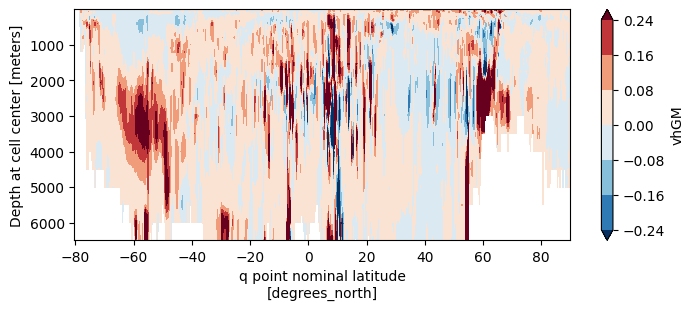

In [28]:
plt.figure(figsize=(8,3))

(dsz_month_1.vhGM.mean(['time','xh'])/25e3/100).plot.contourf(robust=True)
plt.gca().invert_yaxis()

In [30]:
ds_month_1

<xarray.Dataset> Size: 75MB
Dimensions:     (xh: 1440, yh: 1080, time: 12, nv: 2)
Coordinates:
  * xh          (xh) float64 12kB -299.7 -299.5 -299.2 ... 59.53 59.78 60.03
  * yh          (yh) float64 9kB -80.39 -80.31 -80.23 ... 89.73 89.84 89.95
  * time        (time) object 96B 1977-01-16 12:00:00 ... 1977-12-16 12:00:00
  * nv          (nv) float64 16B 1.0 2.0
Data variables:
    MLD_003     (time, yh, xh) float32 75MB ...
    average_T1  (time) datetime64[ns] 96B ...
    average_T2  (time) datetime64[ns] 96B ...
    average_DT  (time) timedelta64[ns] 96B ...
    time_bnds   (time, nv) timedelta64[ns] 192B ...
Attributes:
    filename:   19770101.ocean_month_00721255.nc
    title:      OM4_SIS2_cgrid_025
    grid_type:  regular
    grid_tile:  N/A

In [31]:
dsz_month_1

<xarray.Dataset> Size: 32GB
Dimensions:         (xh: 1440, yh: 1080, z_l: 35, z_i: 36, time: 12, nv: 2,
                     xq: 1440, yq: 1080)
Coordinates:
  * xh              (xh) float64 12kB -299.7 -299.5 -299.2 ... 59.53 59.78 60.03
  * yh              (yh) float64 9kB -80.39 -80.31 -80.23 ... 89.73 89.84 89.95
  * z_l             (z_l) float64 280B 2.5 10.0 20.0 ... 5.5e+03 6e+03 6.5e+03
  * z_i             (z_i) float64 288B 0.0 5.0 15.0 ... 6.25e+03 6.75e+03
  * time            (time) object 96B 1977-01-16 12:00:00 ... 1977-12-16 12:0...
  * nv              (nv) float64 16B 1.0 2.0
  * xq              (xq) float64 12kB -299.6 -299.3 -299.1 ... 59.66 59.91 60.16
  * yq              (yq) float64 9kB -80.35 -80.27 -80.19 ... 89.78 89.89 90.0
Data variables: (12/16)
    so              (time, z_l, yh, xh) float32 3GB ...
    uo              (time, z_l, yh, xq) float32 3GB ...
    vo              (time, z_l, yq, xh) float32 3GB ...
    thetao          (time, z_l, yh, xh) float32 3GB ...
    vmo             (time, z_l, yq, xh) float32 3GB ...
    umo             (time, z_l, yh, xq) float32 3GB ...
    ...              ...
    uhGM            (time, z_l, yh, xq) float32 3GB ...
    vhGM            (time, z_l, yq, xh) float32 3GB nan nan nan ... nan nan nan
    average_T1      (time) datetime64[ns] 96B ...
    average_T2      (time) datetime64[ns] 96B ...
    average_DT      (time) timedelta64[ns] 96B ...
    time_bnds       (time, nv) timedelta64[ns] 192B ...
Attributes:
    filename:   19770101.ocean_month_z_00721255.nc
    title:      OM4_SIS2_cgrid_025
    grid_type:  regular
    grid_tile:  N/A

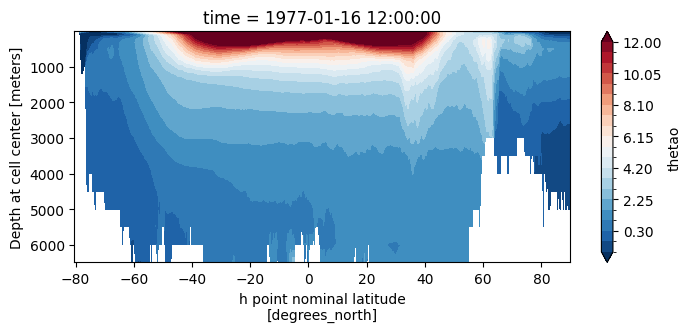

In [5]:
plt.figure(figsize=(8,3))

(dsz_month_1.thetao.mean(['xh'])).isel(time=0).plot.contourf(levels=np.linspace(-1, 12,21))
plt.gca().invert_yaxis()

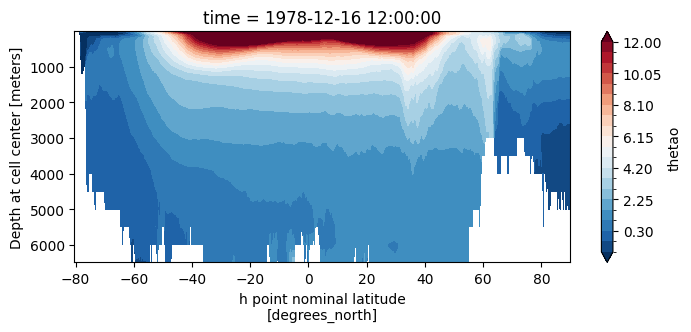

In [6]:
plt.figure(figsize=(8,3))

(dsz_month_2.thetao.mean(['xh'])).isel(time=-1).plot.contourf(levels=np.linspace(-1, 12,21))
plt.gca().invert_yaxis()

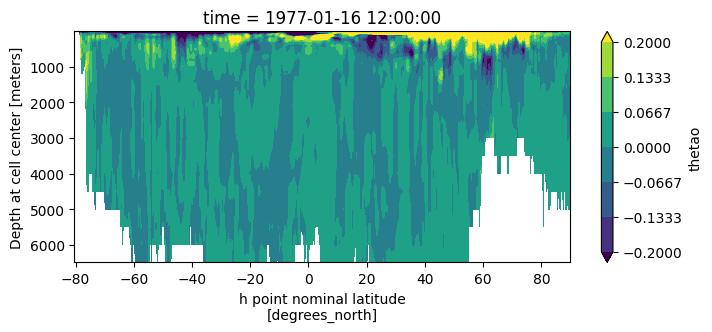

In [9]:
plt.figure(figsize=(8,3))

((dsz_month_2.thetao.mean(['xh'])).isel(time=-1) - (dsz_month_1.thetao.mean(['xh'])) ).isel(time=0).plot.contourf(vmin=-0.2, vmax=0.2)
plt.gca().invert_yaxis()

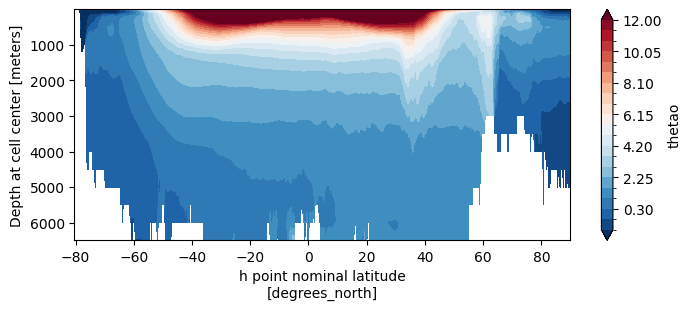

In [ ]:
plt.figure(figsize=(8,3))

(dsz_month_1.thetao.mean(['time','xh'])).plot.contourf(levels=np.linspace(-1, 12,21))
plt.gca().invert_yaxis()

In [35]:
plt.figure(figsize=(8,3))

(dsz_month_2.thetao.mean(['time','xh'])).plot.contourf(levels=np.linspace(-1, 12,21))
plt.gca().invert_yaxis()

: 